<a href="https://colab.research.google.com/github/GARAM-SHIN/AI/blob/main/AI_05_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118


In [ ]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())

2.5.1+cu121
CUDA available: False


In [ ]:
import numpy as np
import torch

A = torch.tensor([[1., -1.], [1., -1.]])
print('A = ', A)
B = torch.tensor(np.array([[1, 2, 3], [4, 5, 6]]))
print('B = ', B)

C = torch.rand(3,3)
print('C = ', C)

D = C.numpy()
print('D = ', D)

E = B.view(1,1,2,3)
print('E = ', E)

print('sum of A = ', A.sum())
print('mean of A = ', A.mean())

A =  tensor([[ 1., -1.],
        [ 1., -1.]])
B =  tensor([[1, 2, 3],
        [4, 5, 6]])
C =  tensor([[0.7131, 0.3565, 0.8785],
        [0.5122, 0.5332, 0.2192],
        [0.4235, 0.4716, 0.2363]])
D =  [[0.71312475 0.3565064  0.87846583]
 [0.5122293  0.53316915 0.2192052 ]
 [0.42348087 0.4716429  0.23633945]]
E =  tensor([[[[1, 2, 3],
          [4, 5, 6]]]])
sum of A =  tensor(0.)
mean of A =  tensor(0.)


In [ ]:
import torch

data = [[1,2],[3,4]]
x_data = torch.tensor(data)

import numpy as np
np_array = np.array(data)
tensor_from_numpy=torch.from_numpy(np_array)

x_zeros = torch.zeros(2,3)

x_ones = torch.ones(3,2)

x_rand = torch.randn(2,2)

random_uniform=torch.rand(3,3)

int_tensor=torch.tensor([1,2,3],dtype=torch.int32)

float_tensor = torch.tensor([1.0,2.0,3.0],dtype=torch.float32)

tensor_a=torch.rand(3,3)
ones_like_a = torch.ones_like(tensor_a)

In [ ]:
import torch

if torch.cuda.is_available():
  tensor = torch.randn(3,3)

  tensor_gpu=tensor.to('cuda')

  print("Tensor moved to GPU:", tensor_gpu)
else:
  print("CUDA is not available. Tensor cannot be moved to GPU.")

CUDA is not available. Tensor cannot be moved to GPU.


In [ ]:
import torch

x=torch.tensor([2.0,3.0,4.0],requires_grad=True)

y=3*(x**2)

z=y.sum()

z.backward()

print(x.grad)

tensor([12., 18., 24.])


In [ ]:
import torch
x=torch.tensor([[2.]],requires_grad=True)
print('x = ', x)
print('x.data = ', x.data)
print('x.grad = ', x.grad)
print('x.grad_fn() = ', x.grad_fn)
y = x * x * 3
print('\ny = ', y)
print('y.data = ', y.data)
print('y.grad = ', y.grad)
print('y.grad_fn() = ', y.grad_fn)
z = y**2
print('\nz = ', z)
print('z.data = ', z.data)
print('z.grad = ', z.grad)
z.backward( )
print('\nAfter invocation of backward()')
print('\nx = ', x)
print('x.data = ', x.data)
print('x.grad = ', x.grad)
print('x.grad_fn( ) = ', x.grad_fn)
print('\ny = ', y)
print('y.data = ', y.data)
print('y.grad = ', y.grad)
print('y.grad_fn( ) = ', y.grad_fn)
print('\nz = ', z)
print('z.data = ', z.data)
print('z.grad = ', z.grad)

x =  tensor([[2.]], requires_grad=True)
x.data =  tensor([[2.]])
x.grad =  None
x.grad_fn() =  None

y =  tensor([[12.]], grad_fn=<MulBackward0>)
y.data =  tensor([[12.]])
y.grad =  None
y.grad_fn() =  <MulBackward0 object at 0x7d3425f14f70>

z =  tensor([[144.]], grad_fn=<PowBackward0>)
z.data =  tensor([[144.]])
z.grad =  None

After invocation of backward()

x =  tensor([[2.]], requires_grad=True)
x.data =  tensor([[2.]])
x.grad =  tensor([[288.]])
x.grad_fn( ) =  None

y =  tensor([[12.]], grad_fn=<MulBackward0>)
y.data =  tensor([[12.]])
y.grad =  None
y.grad_fn( ) =  <MulBackward0 object at 0x7d3425f17ee0>

z =  tensor([[144.]], grad_fn=<PowBackward0>)
z.data =  tensor([[144.]])
z.grad =  None


<ipython-input-8-ac4523db432f>:10: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  print('y.grad = ', y.grad)
<ipython-input-8-ac4523db432f>:15: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleNeuralNet(nn.Module):
  def __init__(self, input_size,hidden_size, num_classed):
    super(SimpleNeuralNet, self).__init__()
    self.fc1 = nn.Linear(input_size, hidden_size)
    self.fc2 = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = self.fc2(x)
    return x

input_size = 784
hidden_size = 500
num_classes = 10

model = SimpleNeuralNet(input_size, hidden_size, num_classes)

print(model)

SimpleNeuralNet(
  (fc1): Linear(in_features=784, out_features=500, bias=True)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
)


In [ ]:
import torch
import torch.nn as nn

class SimpleNet(nn.Module):
  def __init__(self):
    super(SimpleNet,self).__init__()
    self.fc1 = nn.Linear(10,5)
    self.fc2 = nn.Linear(5,2)

  def forward(self,x):
    x = torch.relu(self.fc1(x))
    x = self.fc2(x)
    return x

net = SimpleNet()

for param in net.parameters():
  print(param)

class SimpleNet(nn.Module):
  def __init__(self):
    super(SimpleNet,self).__init__()
    self.fc1 = nn.Linear(10,5)
    self.fc2 = nn.Linear(5,2)

  def forward(self,x):
    x = torch.relu(self.fc1(x))
    x = self.fc2(x)
    return x

net = SimpleNet()

torch.save(net.state_dict(),'model_weights.pth')

print("Model's state dict saved as 'model_weights.pth'")

class SimpleNet(nn.Module):
  def __init__(self):
    super(SimpleNet,self).__init__()
    self.fc1 = nn.Linear(10,5)
    self.fc2 = nn.Linear(5,2)

  def forward(self,x):
    x = torch.relu(self.fc1(x))
    x = self.fc2(x)
    return x

net = SimpleNet()

net.load_state_dict(torch.load('model_weights.pth'))

Parameter containing:
tensor([[ 0.0319,  0.0688,  0.0221, -0.2557,  0.1308, -0.2629,  0.2386,  0.1762,
          0.0510,  0.1174],
        [-0.0108,  0.2107, -0.2035,  0.0635, -0.0342,  0.0850,  0.0081,  0.1663,
          0.1524,  0.0083],
        [-0.2449,  0.1610,  0.1150,  0.0080,  0.2871, -0.0356, -0.2085,  0.2872,
          0.1500, -0.0248],
        [-0.1200, -0.0448, -0.2771,  0.2880, -0.1404,  0.1912, -0.1128, -0.2085,
         -0.2395,  0.0409],
        [-0.1125, -0.0850,  0.2010,  0.2438,  0.2815, -0.0486,  0.0719,  0.1493,
         -0.2255, -0.0681]], requires_grad=True)
Parameter containing:
tensor([ 0.1752, -0.0589, -0.1954, -0.1773,  0.2419], requires_grad=True)
Parameter containing:
tensor([[ 0.1229, -0.3033,  0.2043,  0.2633, -0.0449],
        [ 0.0928, -0.0256,  0.0905, -0.1655, -0.2988]], requires_grad=True)
Parameter containing:
tensor([ 0.2980, -0.0718], requires_grad=True)
Model's state dict saved as 'model_weights.pth'


<ipython-input-10-1ebb6446e839>:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load('model_weights.pth'))


<All keys matched successfully>

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
  def __init__(self, data, labels):
    self.data = data
    self.labels = labels

  def __len__(self):
    return len(self.data)

  def __getitem__(self, index):
    return self.data[index], self.labels[index]

data = torch.randn(100, 10)
labels = torch.randint(0, 2, (100,))

dataset = CustomDataset(data, labels)

dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

for batch in dataloader:
  batch_data, batch_labels = batch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class SimpleModel(nn.Module):
  def __init__(self):
    super(SimpleModel, self).__init__()
    self.fc1 = nn.Linear(10, 50)
    self.dropout = nn.Dropout(0.25)
    self.fc2 = nn.Linear(50, 2)

  def forward(self, x):
    x = torch.relu(self.fc1(x))
    x = self.dropout(x)
    return x

model = SimpleModel()

criterion = nn.CrossEntropyLoss()
Optimizer = optim.SGD(model.parameters(), lr=0.01)

inputs = torch.randn(5, 10)
labels = torch.randint(0, 2, (5,))

model.train()
for epoch in range(5):
  Optimizer.zero_grad()

  outputs = model(inputs)
  loss = criterion(outputs, labels)

  loss.backward()
  Optimizer.step()

model.eval()
with torch.no_grad():
  outputs = model(inputs)

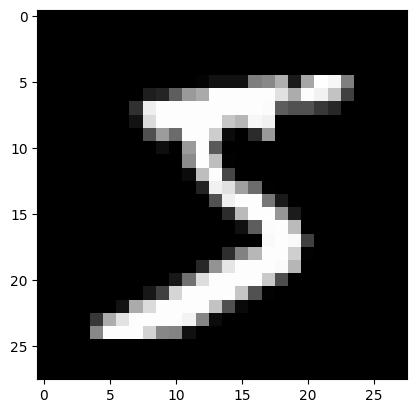

이미지 레이블 : 5
시작 정확도: 1060/10000 (11%)
에포크 0: 완료
학습중 정확도: 9501/10000 (95%)
에포크 1: 완료
학습중 정확도: 9573/10000 (96%)
에포크 2: 완료
학습중 정확도: 9519/10000 (95%)
에포크 3: 완료
학습중 정확도: 9592/10000 (96%)
에포크 4: 완료
학습중 정확도: 9625/10000 (96%)
에포크 5: 완료
학습중 정확도: 9604/10000 (96%)
에포크 6: 완료
학습중 정확도: 9629/10000 (96%)
에포크 7: 완료
학습중 정확도: 9644/10000 (96%)
에포크 8: 완료
학습중 정확도: 9655/10000 (97%)
에포크 9: 완료
학습중 정확도: 9651/10000 (97%)
학습 후 정확도: 9651/10000 (97%)
10 번째 학습데이터의 테스트 결과 : tensor([-6.5807,  3.7683, -6.0469, -8.7804, -1.1517, -8.8507, -7.1320, -5.5124,
        -0.2384, -2.6112], grad_fn=<ViewBackward0>)
10번째 데이터의 예측 : 1
실제 레이블 : 1


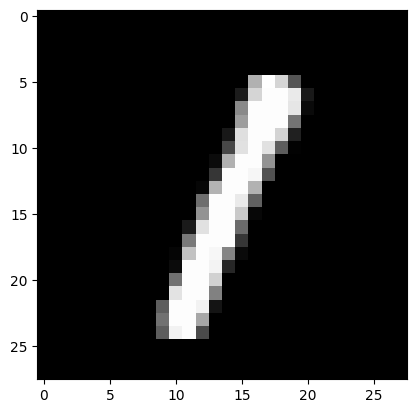

In [ ]:
#-*- coding: utf-8 -*-

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, cache=True)

X = mnist.data.to_numpy() / 255
y = mnist.target.astype(int).to_numpy()

import matplotlib.pyplot as plt
plt.imshow(X[0].reshape(28, 28), cmap='gray')
plt.show()
print("이미지 레이블 : {}".format(y[0]))

import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/7, random_state=0)
X_train = torch.Tensor(X_train)
X_test = torch.Tensor(X_test)
y_train = torch.LongTensor(list(map(int, y_train)))
y_test = torch.LongTensor(list(map(int, y_test)))
ds_train = TensorDataset(X_train, y_train)
ds_test = TensorDataset(X_test, y_test)
loader_train = DataLoader(ds_train, batch_size=64, shuffle=True)
loader_test = DataLoader(ds_test, batch_size=64, shuffle=False)

from torch import nn
model = nn.Sequential()
model.add_module('fc1', nn.Linear(28*28*1, 100))
model.add_module('relu1', nn.ReLU())
model.add_module('fc2', nn.Linear(100, 100))
model.add_module('relu2', nn.ReLU())
model.add_module('fc3', nn.Linear(100, 10))

from torch import optim
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

def train(epoch):
  model.train()
  for data, targets in loader_train:
    optimizer.zero_grad()
    outputs = model(data)
    loss = loss_fn(outputs, targets)
    loss.backward()
    optimizer.step()
  print('에포크 {}: 완료'.format(epoch))

def test(head):
  model.eval()
  correct = 0
  with torch.no_grad():
    for data, targets in loader_test:
      outputs = model(data)
      _, predicted = torch.max(outputs.data, 1)
      correct += predicted.eq(targets.data.view_as(predicted)).sum()
  data_num = len(loader_test.dataset)
  print('{} 정확도: {}/{} ({:.0f}%)'.format(head, correct, data_num, 100. * correct / data_num))

test('시작')
for epoch in range(10):
  train(epoch)
  test('학습중')
test('학습 후')

index = 10
model.eval()
data = X_test[index]
output = model(data)
print('{} 번째 학습데이터의 테스트 결과 : {}'.format(index,output))
_, predicted = torch.max(output.data, 0)
print('{}번째 데이터의 예측 : {}'.format(index,predicted))
X_test_show = (X_test[index]).numpy()
plt.imshow(X_test_show.reshape(28,28),cmap='gray')
print('실제 레이블 : {}'.format(y_test[index]))

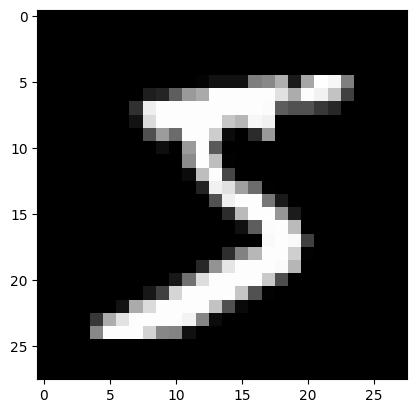

이미지 레이블 : 5


In [ ]:
#-*- coding: utf-8 -*-

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, cache=True)

X = mnist.data.to_numpy() / 255
y = mnist.target.astype(int).to_numpy()

import matplotlib.pyplot as plt
plt.imshow(X[0].reshape(28, 28), cmap='gray')
plt.show()
print("이미지 레이블 : {}".format(y[0]))

import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/7, random_state=0)
X_train = torch.Tensor(X_train)
X_test = torch.Tensor(X_test)
y_train = torch.LongTensor(list(map(int, y_train)))
y_test = torch.LongTensor(list(map(int, y_test)))
ds_train = TensorDataset(X_train, y_train)
ds_test = TensorDataset(X_test, y_test)
loader_train = DataLoader(ds_train, batch_size=64, shuffle=True)
loader_test = DataLoader(ds_test, batch_size=64, shuffle=False)

from torch import nn
model = nn.Sequential()
model.add_module('fc1', nn.Linear(28*28*1, 100))
model.add_module('relu1', nn.ReLU())
model.add_module('fc2', nn.Linear(100, 100))
model.add_module('relu2', nn.ReLU())
model.add_module('fc3', nn.Linear(100, 10))

from torch import optim
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

def train(epoch):
  model.train()
  for data, targets in loader_train:
    optimizer.zero_grad()
    outputs = model(data)
    loss = loss_fn(outputs, targets)
    loss.backward()
    optimizer.step()
  print('에포크 {}: 완료'.format(epoch))

def test(head):
  model.eval()
  correct = 0
  with torch.no_grad():
    for data, targets in loader_test:
      outputs = model(data)
      _, predicted = torch.max(outputs.data, 1)
      correct += predicted.eq(targets.data.view_as(predicted)).sum()
  data_num = len(loader_test.dataset)
  print('accuracy = ', 100*correct/data_num)

In [ ]:
for epoch in range(3):
    train(epoch)
    test('학습중')

에포크 0: 완료
accuracy =  tensor(94.8900)
에포크 1: 완료
accuracy =  tensor(95.2000)
에포크 2: 완료
accuracy =  tensor(95.6400)


In [ ]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, cache=True)
X = mnist.data.to_numpy() / 255
y = mnist.target.astype(int).to_numpy()
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=1/7,random_state=0)
X_train=torch.Tensor(X_train)
X_test=torch.Tensor(X_test)
y_train=torch.LongTensor(list(map(int,y_train)))
y_test=torch.LongTensor(list(map(int,y_test)))
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.autograd import Variable

X_train = X_train.view(-1, 1,28,28).float()
X_test = X_test.view(-1, 1,28,28).float()
print(X_train.shape)
print(X_test.shape)

train = TensorDataset(X_train, y_train)
test = TensorDataset(X_test, y_test)
BATCH_SIZE = 32
loader_train = DataLoader(train, BATCH_SIZE, shuffle=True)
loader_test = DataLoader(test, BATCH_SIZE, shuffle=False)

class CNN(nn.Module):
  def __init__(self):
    super(CNN,self).__init__()
    self.conv1 = nn.Conv2d(1,32,kernel_size=5)
    self.conv2 = nn.Conv2d(32,32,kernel_size=5)
    self.conv3 = nn.Conv2d(32,64,kernel_size=5)
    self.fc1 = nn.Linear(3*3*64,256)
    self.fc2 = nn.Linear(256,10)

    self.loss_fn = nn.CrossEntropyLoss()
    self.optimizer = optim.Adam(self.parameters(), lr=0.01)

  def forward(self,x):
    x = F.relu(self.conv1(x))
    x = F.relu(F.max_pool2d(self.conv2(x),2))
    x = F.dropout(x,p=0.5,training=self.training)
    x = F.relu(F.max_pool2d(self.conv3(x),2))
    x = F.dropout(x,p=0.5,training=self.training)
    x = x.view(-1,3*3*64)
    x = F.relu(self.fc1(x))
    x = F.dropout(x,training=self.training)
    x = self.fc2(x)
    return F.log_softmax(x, dim=1)

def fit(model, loader_train):
    optimizer = torch.optim.Adam(model.parameters())
    error = nn.CrossEntropyLoss()
    EPOCHS = 1
    model.train()
    for epoch in range(EPOCHS):
      correct = 0
      for batch_idx, (X_batch, y_batch) in enumerate(loader_train):
        var_X_batch = Variable(X_batch).float()
        var_y_batch = Variable(y_batch)
        optimizer.zero_grad()
        output = model(var_X_batch)
        loss = error(output, var_y_batch)
        loss.backward()
        optimizer.step()
        predicted = torch.max(output.data, 1)[1]
        correct += (predicted == var_y_batch).sum()
        if batch_idx % 50 == 0:
            print("에포크 : {} [{}/{} ({:.0f}%)]\t 손실함수 : {:.6f}\t Accuracy:{:.3f}%".format(
              epoch, batch_idx * len(X_batch), len(loader_train),
              100. * batch_idx / len(loader_train),
              loss.data,
              correct * 100. / (BATCH_SIZE * (batch_idx + 1))))
def evaluate(model):
    correct = 0
    for test_imgs, test_labels in loader_test:
      test_imgs = Variable(test_imgs).float()
      output = model(test_imgs)
      predicted = torch.max(output, 1)[1]
      correct += (predicted == test_labels).sum()
    print("테스트 데이터 정확도: {:.3f}%".format(float(correct) / (len(loader_test) * BATCH_SIZE)))
cnn = CNN()
evaluate(cnn)
fit(cnn, loader_train)
cnn.eval()
evaluate(cnn)
index = 10
data = X_test[index].view(-1, 1, 28, 28).float()
output = cnn(data)
print("{} 번째 학습데이터의 테스트 결과 : {}".format(index, output))
_, predicted = torch.max(output, 1)
print("{}번째 데이터의 예측 : {}".format(index, predicted.numpy()))
print("실제 레이블 : {}".format(y_test[index]))


torch.Size([60000, 1, 28, 28])
torch.Size([10000, 1, 28, 28])
테스트 데이터 정확도: 0.097%
에포크 : 0 [0/1875 (0%)]	 손실함수 : 2.312925	 Accuracy:6.250%
에포크 : 0 [1600/1875 (3%)]	 손실함수 : 1.165190	 Accuracy:34.130%
에포크 : 0 [3200/1875 (5%)]	 손실함수 : 0.654226	 Accuracy:52.692%
에포크 : 0 [4800/1875 (8%)]	 손실함수 : 0.807811	 Accuracy:63.224%
에포크 : 0 [6400/1875 (11%)]	 손실함수 : 0.341150	 Accuracy:69.512%
에포크 : 0 [8000/1875 (13%)]	 손실함수 : 0.228924	 Accuracy:73.506%
에포크 : 0 [9600/1875 (16%)]	 손실함수 : 0.386250	 Accuracy:76.287%
에포크 : 0 [11200/1875 (19%)]	 손실함수 : 0.444707	 Accuracy:78.365%
에포크 : 0 [12800/1875 (21%)]	 손실함수 : 0.373167	 Accuracy:80.003%
에포크 : 0 [14400/1875 (24%)]	 손실함수 : 0.082750	 Accuracy:81.423%
에포크 : 0 [16000/1875 (27%)]	 손실함수 : 0.084617	 Accuracy:82.678%
에포크 : 0 [17600/1875 (29%)]	 손실함수 : 0.048816	 Accuracy:83.655%
에포크 : 0 [19200/1875 (32%)]	 손실함수 : 0.344561	 Accuracy:84.526%
에포크 : 0 [20800/1875 (35%)]	 손실함수 : 0.072606	 Accuracy:85.133%
에포크 : 0 [22400/1875 (37%)]	 손실함수 : 0.082795	 Accuracy:85.757%
에포크